<a href="https://colab.research.google.com/github/Bonrice/Google-Colab-Projects/blob/main/Steam_Dataset_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark

In [ ]:
reviews = spark.read.csv('/content/drive/MyDrive/steam_dataset/reviews.csv', header=True)
reviews.select('created_at','updated_at').show(truncate=False)

+--------------------------------+--------------------------------+
|created_at                      |updated_at                      |
+--------------------------------+--------------------------------+
|2025-09-07 12:51:00.564782+00:00|2025-09-08 00:47:55.754043+00:00|
|2025-09-07 12:51:00.564782+00:00|2025-09-08 00:47:55.754043+00:00|
|2025-09-07 12:51:00.564782+00:00|2025-09-08 00:47:55.754043+00:00|
|NULL                            |NULL                            |
|NULL                            |NULL                            |
|NULL                            |NULL                            |
|NULL                            |NULL                            |
|2025-09-07 12:51:00.564782+00:00|2025-09-08 00:47:55.754043+00:00|
|NULL                            |NULL                            |
|NULL                            |NULL                            |
|NULL                            |NULL                            |
|NULL                            |NULL          

In [ ]:
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
reviews = spark.read.csv('/content/drive/MyDrive/steam_dataset/reviews.csv', header=True)

# Apply the timestamp conversion to new columns
reviews = reviews.withColumn("review_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('review_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

reviews.select('review_created_at','review_updated_at').show(truncate=False)
reviews.printSchema()

+--------------------------+--------------------------+
|review_created_at         |review_updated_at         |
+--------------------------+--------------------------+
|2025-09-07 12:51:00.564782|2025-09-08 00:47:55.754043|
|2025-09-07 12:51:00.564782|2025-09-08 00:47:55.754043|
|2025-09-07 12:51:00.564782|2025-09-08 00:47:55.754043|
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|2025-09-07 12:51:00.564782|2025-09-08 00:47:55.754043|
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                      |
|NULL                      |NULL                

In [ ]:
from IPython.core import application
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
application = spark.read.csv('/content/drive/MyDrive/steam_dataset/applications.csv', header=True)

# Apply the timestamp conversion to new columns
application = application.withColumn("application_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('application_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

application.select('application_created_at','application_updated_at').show(truncate=False)
application.printSchema()

+--------------------------+--------------------------+
|application_created_at    |application_updated_at    |
+--------------------------+--------------------------+
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 06:04:55.062108|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.107239|
|2025-09-07 16:27:12.218587|2025-09-29 02:01:37.

In [ ]:
merged_df = application.join(reviews, on='appid', how='left')
merged_df.printSchema()


root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- required_age: string (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- background: string (nullable = true)
 |-- metacritic_score: string (nullable = true)
 |-- recommendations_total: string (nullable = true)
 |-- mat_supports_windows: string (nullable = true)
 |-- mat_supports_mac: string (nullable = true)
 |-- mat_supports_linux: string (nullable = true)
 |-- mat_initial_price: string (nullable = true)
 |-- mat_final_price: string (nullable = true)
 |-- mat_discount_percent: string (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: string (nullable = true)
 |-- mat_pc_os_min: string (nullable = true)
 |-- mat_pc_processor_min: strin

In [ ]:
from pyspark.sql.functions import to_timestamp, col, lit, try_to_timestamp
from pyspark.sql.types import BooleanType, IntegerType, DoubleType, LongType

steam = merged_df.withColumn('author_num_games_owned', col('author_num_games_owned').cast(IntegerType())) \
          .withColumn('author_num_reviews', col('author_num_reviews').cast(DoubleType())) \
          .withColumn('author_playtime_forever', col('author_playtime_forever').cast(DoubleType())) \
          .withColumn('author_playtime_last_two_weeks', col('author_playtime_last_two_weeks').cast(DoubleType())) \
          .withColumn('author_playtime_at_review', col('author_playtime_at_review').cast(DoubleType())) \
          .withColumn('timestamp_created', try_to_timestamp(col('timestamp_created'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('timestamp_updated', try_to_timestamp(col('timestamp_updated'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('weighted_vote_score', col('weighted_vote_score').cast(DoubleType())) \
          .withColumn('comment_count', col('comment_count').cast(DoubleType())) \
          .withColumn('steam_purchase', col('steam_purchase').cast(BooleanType())) \
          .withColumn('received_for_free', col('received_for_free').cast(BooleanType())) \
          .withColumn('written_during_early_access', col('written_during_early_access').cast(BooleanType())) \
          .withColumn('is_free', col('is_free').cast(BooleanType())) \
          .withColumn('release_date', try_to_timestamp(col('release_date'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('required_age', col('required_age').cast(DoubleType())) \
          .withColumn('metacritic_score', col('metacritic_score').cast(DoubleType())) \
          .withColumn('recommendations_total', col('recommendations_total').cast(DoubleType())) \
          .withColumn('mat_supports_windows', col('mat_supports_windows').cast(BooleanType())) \
          .withColumn('mat_supports_mac', col('mat_supports_mac').cast(BooleanType())) \
          .withColumn('mat_supports_linux', col('mat_supports_linux').cast(BooleanType())) \
          .withColumn('mat_initial_price', col('mat_initial_price').cast(DoubleType())) \
          .withColumn('mat_final_price', col('mat_final_price').cast(DoubleType())) \
          .withColumn('mat_discount_percent', col('mat_discount_percent').cast(DoubleType())) \
          .withColumn('mat_achievement_count', col('mat_achievement_count').cast(DoubleType())) \
          #.withColumn('app_updated_at', try_to_timestamp(col('app_updated_at'), lit('yyyy-MM-dd HH:mm:ss'))) \
          #.withColumn('app_created_at', try_to_timestamp(col('app_created_at'), lit('yyyy-MM-dd HH:mm:ss')))
 # .withColumn('review_created_at', try_to_timestamp(col('review_created_at'), lit('yyyy-MM-dd HH:mm:ss'))) \
         # .withColumn('review_updated_at', try_to_timestamp(col('review_updated_at'), lit('yyyy-MM-dd HH:mm:ss'))) \
#.withColumn('voted_up', col('voted_up').cast(BooleanType())) \
#.withColumn('votes_up', (col('votes_up').cast(DoubleType()))) \
          #.withColumn('votes_funny', col('votes_funny').cast(DoubleType())) \
print('Schema:')
steam.printSchema()

Schema:
root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- required_age: double (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- background: string (nullable = true)
 |-- metacritic_score: double (nullable = true)
 |-- recommendations_total: double (nullable = true)
 |-- mat_supports_windows: boolean (nullable = true)
 |-- mat_supports_mac: boolean (nullable = true)
 |-- mat_supports_linux: boolean (nullable = true)
 |-- mat_initial_price: double (nullable = true)
 |-- mat_final_price: double (nullable = true)
 |-- mat_discount_percent: double (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: double (nullable = true)
 |-- mat_pc_os_min: string (nullable = true)
 |-- mat_pc_proce

In [ ]:
steam = steam.drop('header_image','background','mat_pc_os_min','mat_pc_processor_min','mat_pc_memory_min','mat_pc_graphics_min','mat_pc_os_rec','mat_pc_processor_rec','mat_pc_memory_rec','mat_pc_graphics_rec','created_at','updated_at')

In [ ]:
steam.show(5)

+-------+--------------------+----+-------+------------+------------+--------------------+--------------------+----------------+---------------------+--------------------+----------------+------------------+-----------------+---------------+--------------------+------------+---------------------+----------------------+----------------------+--------------------+--------------------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+--------------------+--------------------+
|  appid|                name|type|is_free|release_date|required_age|   short_description| supported_languages|metacritic_score|recommendations_total|mat_supports_windows|mat_supports_mac|mat_supports_linux|mat_initial_price|mat_final_pric

Total number of reviews

In [ ]:
steam.count()

1170529

Unique number of reviewers

In [ ]:
steam.select('author_steamid').distinct().count()

701898

Number of reviews per game

In [ ]:
steam.groupby('appid','name').count().orderBy('count', ascending=False).show(5)

+-------+----------------------------+-----+
|  appid|                        name|count|
+-------+----------------------------+-----+
|    400|                      Portal|  101|
|1003750|她2 : 我还想再见到你   He...|  100|
|1011900|        Mirror: Enchantin...|  100|
|1007800|        Single Diary: Fre...|  100|
|1021670|                    机退怪兽|  100|
+-------+----------------------------+-----+
only showing top 5 rows


Filter down on English language supported games

In [ ]:
from pyspark.sql.functions import col, lower
english = steam.filter(lower(col('supported_languages')).contains('english'))
english.groupby('appid','name').count().orderBy('count', ascending=False).show()

+-------+----------------------------+-----+
|  appid|                        name|count|
+-------+----------------------------+-----+
|    400|                      Portal|  101|
|1016800|        Chernobylite Comp...|  100|
|1040200|         Crime Scene Cleaner|  100|
|1044870|        Zero-based World-...|  100|
| 107410|                      Arma 3|  100|
|  10180|        Call of Duty®: Mo...|  100|
|1041400|        Fight Angel/格斗天使|  100|
|1001270|        Kebab Chefs! - Re...|  100|
|1017900|        Age of Empires: D...|  100|
|  10195|        Call of Duty®: Mo...|  100|
|1042160|        The Islander: Tow...|  100|
|1003750|她2 : 我还想再见到你   He...|  100|
|1032830|                   Eldervale|  100|
|1021210|        Cyber Knights: Fl...|  100|
|1049410|                Superliminal|  100|
|1009821|        Dead by Daylight ...|  100|
|1073490|           Monster X Monster|  100|
|1012880|        60 Seconds! Reato...|  100|
|1049790|        Space Engineers -...|  100|
|1044720|           Fa

Filter down on Reviews in English

In [ ]:
from pyspark.sql.functions import col, lower
english = steam.filter(lower(col('language')).contains('english'))
english.groupby('appid','name').count().orderBy('count', ascending=False).show()

+-------+--------------------+-----+
|  appid|                name|count|
+-------+--------------------+-----+
|2482440|Leap up no Justu:...|  100|
|2489990|   Jeepney Simulator|  100|
| 560710|    Leap Up no jutsu|   99|
|2389930|Ayase, the Sexy A...|   99|
|3435260|     Dice With Death|   98|
| 932980|  Axis Football 2018|   98|
|1098210|  Axis Football 2019|   97|
|2587590|              Iridio|   97|
|3230400|EA SPORTS™ Madden...|   97|
|3615160|Teddy's Haven - A...|   96|
| 408900|Unfortunate Spacemen|   96|
| 611150|        your sisters|   96|
|3126530|Jupiter Hell Classic|   95|
| 674850|2MD: VR Football ...|   95|
|1281170|Pro Strategy Foot...|   95|
| 766040|Gloom: Digital Ed...|   95|
|3005620|        Drop Pockets|   95|
|3519530|       Merge Maestro|   95|
| 932500|       Damned Daniel|   95|
|1058180|OMSI 2 Add-On Mas...|   94|
+-------+--------------------+-----+
only showing top 20 rows


Select votes columns to understand a games success

In [ ]:
steam.select('voted_up','votes_up','votes_funny').distinct().show()

+--------------------+--------------------+--------------------+
|            voted_up|            votes_up|         votes_funny|
+--------------------+--------------------+--------------------+
|               False|                   4|                   3|
|                True|                  23|                  10|
|                True|                   4|                  20|
| no matter how ma...|          1556983219|          1556983219|
|               False|                   6|                   6|
|          1601844313|          1601844313|                True|
|                True|                  87|                  15|
|                True|                  37|                  37|
| признанием в общ...| даешь согласие и...| знакомишься с но...|
|                True|                   6|                   9|
|                True|                 100|                  67|
|                True|                  84|                  16|
| and despite some...| re

the same as above filtered on English reviews

In [ ]:
english.select('voted_up','votes_up','votes_funny').distinct().show()

+--------------------+--------------------+--------------------+
|            voted_up|            votes_up|         votes_funny|
+--------------------+--------------------+--------------------+
|               False|                   4|                   3|
|               False|                  89|                   1|
|          1637850298|                True|                   0|
|          1641095077|                True|                   3|
|          1643496027|               False|                   3|
|                True|                  23|                  10|
|               False|                   6|                   6|
| but the levels a...| the idea with ma...| but all this qui...|
|          1648148282|          1648148282|                True|
|          1651715539|                True|                   0|
|          1657376641|                True|                   1|
| it doesn't do mu...|         no ""goal""| no ""meaning"" -...|
|               False|   

voted_up should be a boolean to show thumbs up or down on a positive or negative game review

In [ ]:
from pyspark.sql import functions as F
df_bools = english.filter(F.col("voted_up").try_cast("boolean").isNotNull())
df_bools.select("voted_up").distinct().show(200, truncate=False)
df_bools

+--------+
|voted_up|
+--------+
|False   |
|True    |
+--------+



DataFrame[appid: string, name: string, type: string, is_free: boolean, release_date: timestamp, required_age: double, short_description: string, supported_languages: string, metacritic_score: double, recommendations_total: double, mat_supports_windows: boolean, mat_supports_mac: boolean, mat_supports_linux: boolean, mat_initial_price: double, mat_final_price: double, mat_discount_percent: double, mat_currency: string, mat_achievement_count: double, application_updated_at: timestamp, application_created_at: timestamp, recommendationid: string, author_steamid: string, author_num_games_owned: int, author_num_reviews: double, author_playtime_forever: double, author_playtime_last_two_weeks: double, author_playtime_at_review: double, author_last_played: string, language: string, review_text: string, timestamp_created: timestamp, timestamp_updated: timestamp, voted_up: string, votes_up: string, votes_funny: string, weighted_vote_score: double, comment_count: double, steam_purchase: boolean, r

In [ ]:
df_bools = df_bools.withColumn('voted_up', col('voted_up').cast(BooleanType()))
df_bools.printSchema()

root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- required_age: double (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- metacritic_score: double (nullable = true)
 |-- recommendations_total: double (nullable = true)
 |-- mat_supports_windows: boolean (nullable = true)
 |-- mat_supports_mac: boolean (nullable = true)
 |-- mat_supports_linux: boolean (nullable = true)
 |-- mat_initial_price: double (nullable = true)
 |-- mat_final_price: double (nullable = true)
 |-- mat_discount_percent: double (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: double (nullable = true)
 |-- application_updated_at: timestamp (nullable = true)
 |-- application_created_at: timestamp (nullable = true)
 |-- recommendationid: string (nullable = 

In [ ]:
df_bools.groupBy('appid','name','voted_up').count().orderBy('count', ascending=False).show()

+-------+--------------------+--------+-----+
|  appid|                name|voted_up|count|
+-------+--------------------+--------+-----+
| 560710|    Leap Up no jutsu|    true|   90|
|2587590|              Iridio|    true|   88|
| 611150|        your sisters|    true|   87|
|   3480|       Peggle Deluxe|    true|   72|
|2389930|Ayase, the Sexy A...|    true|   72|
|1443200|        Class of '09|    true|   70|
| 439650|THE LAST -NARUTO ...|    true|   69|
|2482440|Leap up no Justu:...|    true|   68|
|3873980|        Shadow Lotus|    true|   68|
|2291760|Papa's Freezeria ...|    true|   66|
|  32470|STAR WARS™ Empire...|    true|   65|
|2695570|      Kindergarten 3|    true|   65|
| 926990|WolfQuest: Annive...|    true|   65|
|  22320|The Elder Scrolls...|    true|   64|
| 784080|MechWarrior 5: Me...|    true|   64|
| 286160|  Tabletop Simulator|    true|   63|
|3107330|          Nodebuster|    true|   62|
|1424330|          Wobbledogs|    true|   62|
|3435260|     Dice With Death|    

In [ ]:
df_bools.select('voted_up','votes_up','votes_funny').distinct().show()

+--------+--------+-----------+
|voted_up|votes_up|votes_funny|
+--------+--------+-----------+
|    true|       2|          0|
|   false|       2|          2|
|    true|       5|          5|
|    true|       1|          7|
|    true|      26|         12|
|    true|      29|          7|
|    true|      24|         15|
|    true|     172|         56|
|    true|     101|          0|
|    true|       0|         15|
|    true|      16|         56|
|   false|      25|          0|
|    true|      43|          1|
|   false|      12|          1|
|   false|      43|         20|
|   false|       2|          5|
|   false|      85|          0|
|    true|      22|          7|
|   false|      28|          1|
|   false|      53|          1|
+--------+--------+-----------+
only showing top 20 rows


In [ ]:
df_bools.groupBy('appid','name').agg(
    F.count("voted_up").alias("voted_up_count"),
    F.sum('votes_up').alias('total_votes_up')).show(truncate=False)

+-------+--------------------------------------------------+--------------+--------------+
|appid  |name                                              |voted_up_count|total_votes_up|
+-------+--------------------------------------------------+--------------+--------------+
|1000030|Cook, Serve, Delicious! 3?!                       |10            |5.0           |
|1000120|SinVR - Scarlet’s Luxury Pad                      |2             |13.0          |
|1000130|Cube Defender                                     |1             |1.0           |
|1000140|SinVR - Test Chamber                              |1             |0.0           |
|1000150|SinVR - Mrs. Wilson’s Classroom                   |1             |0.0           |
|1000160|SinVR - Jessica in Seedy Alley                    |1             |0.0           |
|1000170|SinVR - Silent Asylum                             |1             |0.0           |
|1000190|SinVR - Alana Quinn                               |3             |2.0           |

In [ ]:
from pyspark.sql import functions as F

result = (
  df_bools
    .groupBy("appid", "name")
    .agg(
        # Count of True values
        F.sum(F.when(F.col("voted_up") == True, 1).otherwise(0)).alias("true_count"),

        # Count of False values
        F.sum(F.when(F.col("voted_up") == False, 1).otherwise(0)).alias("false_count"),

        # Sum of votes_up for True rows
        F.sum(F.when(F.col("voted_up") == True, F.col("votes_up")).otherwise(0))
            .alias("votes_up_true_sum"),

        # Sum of votes_up for False rows
        F.sum(F.when(F.col("voted_up") == False, F.col("votes_up")).otherwise(0))
            .alias("votes_up_false_sum")
    )
)

result.show(truncate=False)



+-------+--------------------------------------------------+----------+-----------+-----------------+------------------+
|appid  |name                                              |true_count|false_count|votes_up_true_sum|votes_up_false_sum|
+-------+--------------------------------------------------+----------+-----------+-----------------+------------------+
|1000030|Cook, Serve, Delicious! 3?!                       |10        |0          |5                |0                 |
|1000120|SinVR - Scarlet’s Luxury Pad                      |0         |2          |0                |13                |
|1000130|Cube Defender                                     |1         |0          |1                |0                 |
|1000140|SinVR - Test Chamber                              |1         |0          |0                |0                 |
|1000150|SinVR - Mrs. Wilson’s Classroom                   |1         |0          |0                |0                 |
|1000160|SinVR - Jessica in Seed

In [ ]:
result.select('appid','name','true_count','votes_up_true_sum').orderBy('true_count', ascending=False).show(truncate=False)

+-------+----------------------------------------------------------+----------+-----------------+
|appid  |name                                                      |true_count|votes_up_true_sum|
+-------+----------------------------------------------------------+----------+-----------------+
|560710 |Leap Up no jutsu                                          |90        |33               |
|2587590|Iridio                                                    |88        |80               |
|611150 |your sisters                                              |87        |134              |
|3480   |Peggle Deluxe                                             |72        |45               |
|2389930|Ayase, the Sexy Archer                                    |72        |18               |
|1443200|Class of '09                                              |70        |25               |
|439650 |THE LAST -NARUTO THE MOVIE-                               |69        |790              |
|2482440|Leap up no 

In [ ]:
true_result = result.select('appid','name','true_count','votes_up_true_sum').orderBy('votes_up_true_sum', ascending=False)
true_result.show(truncate=False)

+-------+--------------------------------------------------+----------+-----------------+
|appid  |name                                              |true_count|votes_up_true_sum|
+-------+--------------------------------------------------+----------+-----------------+
|1200520|Ascent Free-Roaming VR Experience                 |6         |5825             |
|875670 |Sophisticated Puzzle                              |13        |4566             |
|1200140|4X4 OFF-ROAD CHALLENGE                            |6         |2827             |
|2378900|The Coffin of Andy and Leyley                     |11        |2228             |
|1622940|Dead by Daylight - Terror Expansion Pack          |27        |1955             |
|3556750|Warhammer 40,000: Dawn of War - Definitive Edition|11        |1678             |
|1812160|CUCKOLD SIMULATOR: Coomer's Delight               |29        |1663             |
|29570  |Guild Wars® Trilogy                               |20        |1536             |
|3286930|H

In [ ]:
from pyspark.sql.functions import col

collected_results = true_result.collect()

app = [row[0] for row in collected_results]
name = [row[1] for row in collected_results]
true = [row[2] for row in collected_results]
votes = [row[3] for row in collected_results]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the PySpark DataFrame to a Pandas DataFrame directly
true_pd_df = true_result.toPandas()

# Rename columns for clarity to match the intended use
true_pd_df = true_pd_df.rename(columns={
    'appid': 'App_ID',
    'name': 'Game',
    'true_count': 'Voted_Up', # This column holds the count of 'True' votes
    'votes_up_true_sum': 'Liked' # This column holds the sum of votes_up for 'True' votes
})

true_pd_df.head()

,App_ID,Game,Voted_Up,Liked
0,1200520,Ascent Free-Roaming VR Experience,6,5825
1,875670,Sophisticated Puzzle,13,4566
2,1200140,4X4 OFF-ROAD CHALLENGE,6,2827
3,2378900,The Coffin of Andy and Leyley,11,2228
4,1622940,Dead by Daylight - Terror Expansion Pack,27,1955


In [ ]:
true = pd.DataFrame({'App_ID' : app, 'Game' : name, 'Voted_Up' : true, 'Liked' : votes})
true.head()

,App_ID,Game,Voted_Up,Liked
0,1200520,Ascent Free-Roaming VR Experience,6,5825
1,875670,Sophisticated Puzzle,13,4566
2,1200140,4X4 OFF-ROAD CHALLENGE,6,2827
3,2378900,The Coffin of Andy and Leyley,11,2228
4,1622940,Dead by Daylight - Terror Expansion Pack,27,1955


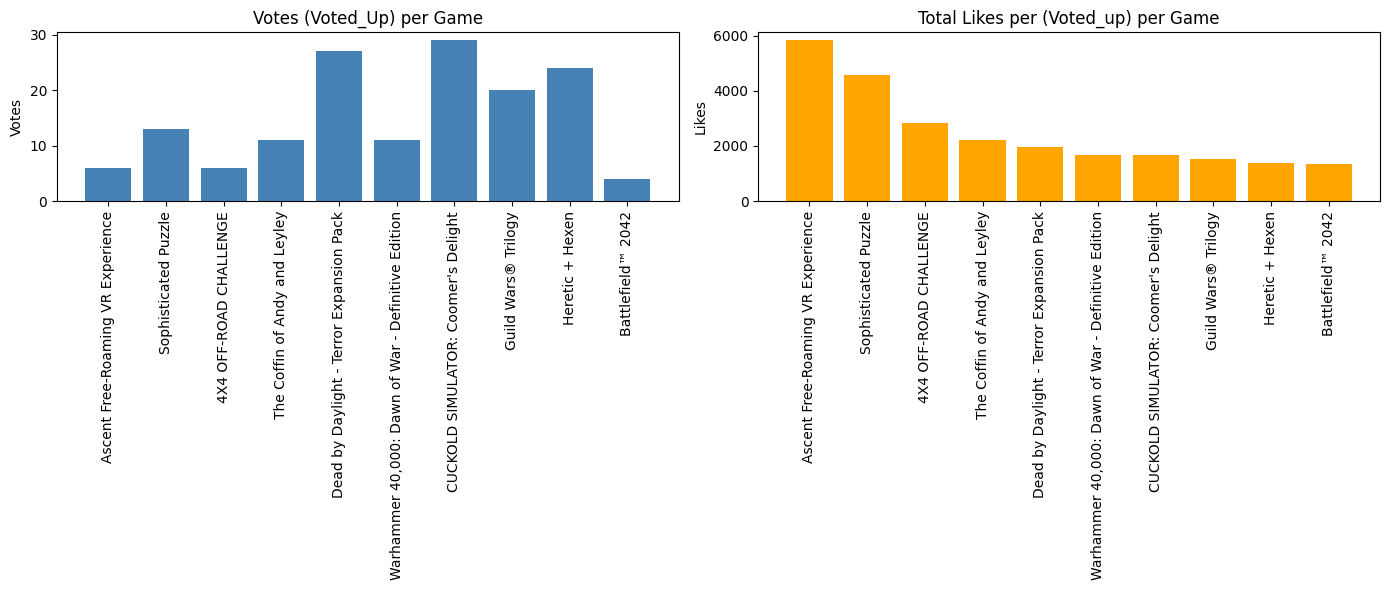

In [ ]:
import matplotlib.pyplot as plt
# Set figure size
true_pd_df_top_10 = true.head(10)
plt.figure(figsize=(14, 6))

# --- Plot 1: Votes ---
plt.subplot(1, 2, 1)
plt.bar(true_pd_df_top_10["Game"], true_pd_df_top_10["Voted_Up"], color="steelblue")
plt.xticks(rotation=90)
plt.title("Votes (Voted_Up) per Game")
plt.ylabel("Votes")
plt.tight_layout()

# --- Plot 2: Likes ---
plt.subplot(1, 2, 2)
plt.bar(true_pd_df_top_10["Game"], true_pd_df_top_10["Liked"], color="orange")
plt.xticks(rotation=90)
plt.title("Total Likes per (Voted_up) per Game")
plt.ylabel("Likes")
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# result_collected = result.collect() # This line converts to a list, which is not needed for toPandas()

# The following list comprehensions are not strictly necessary if the goal is to convert
# the entire DataFrame to Pandas directly, but they don't cause the error.
# app = [row[0] for row in result_collected]
# name = [row[1] for row in result_collected]
# true = [row[2] for row in result_collected]
# false = [row[3] for row in result_collected]
# true_votes = [row[4] for row in result_collected]
# false_votes = [row[5] for row in result_collected]

# Convert the PySpark DataFrame to a Pandas DataFrame directly
true_false_df = result.toPandas()

# Rename columns for clarity to match the intended use
true_false_df = true_false_df.rename(columns={
    'appid': 'App_ID',
    'name': 'Game',
    'true_count': 'Voted_Up',
    'false_count' : 'Voted_Down',# This column holds the count of 'True' votes
    'votes_up_true_sum': 'Voted_Up_Liked',
    'votes_up_false_sum' : 'Voted_Down_Liked'# This column holds the sum of votes_up for 'True' votes
})

true_false_df.head()

,App_ID,Game,Voted_Up,Voted_Down,Voted_Up_Liked,Voted_Down_Liked
0,1000030,"Cook, Serve, Delicious! 3?!",10,0,5,0
1,1000120,SinVR - Scarlet’s Luxury Pad,0,2,0,13
2,1000130,Cube Defender,1,0,1,0
3,1000140,SinVR - Test Chamber,1,0,0,0
4,1000150,SinVR - Mrs. Wilson’s Classroom,1,0,0,0


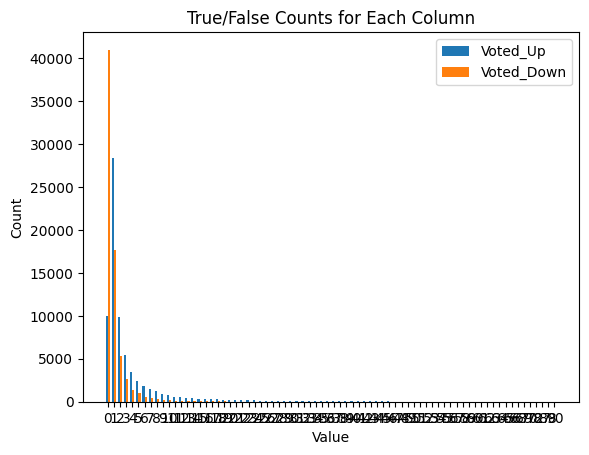

In [ ]:
import numpy as np

columns_to_plot = ['Voted_Up', 'Voted_Down']
counts = {}
for col in columns_to_plot:
    counts[col] = true_false_df[col].value_counts()
counts_df = pd.DataFrame(counts).fillna(0)

# Plotting True/False multi-bar chart
labels = counts_df.index.astype(str)  # True/False as strings
x = np.arange(len(labels))  # label locations
width = 0.35  # width of bars

fig, ax = plt.subplots()
for i, col in enumerate(counts_df.columns):
    ax.bar(x + i*width, counts_df[col], width, label=col)

ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.set_title('True/False Counts for Each Column')
ax.set_xticks(x + width/2)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

In [ ]:
from pyspark.sql.functions import col, regexp_replace, lower, when, lit, expr, trim
from pyspark.sql.types import IntegerType, StringType, BooleanType, LongType

# Helper function to sanitize problematic string columns (removes double quotes, exclamation marks, and trims spaces)
def safe_string_cast(column):
    # Remove leading/trailing spaces, then remove '!' and '"' characters
    cleaned_col = trim(column)
    cleaned_col = regexp_replace(cleaned_col, '!', '')
    cleaned_col = regexp_replace(cleaned_col, '"', '')
    # Ensure it's explicitly a StringType
    return cleaned_col.cast(StringType())

# Re-evaluate all columns that are intended to be boolean and apply try_cast(BooleanType())
# to robustly handle any values that might still cause issues.
# This is particularly relevant if the problematic string somehow ended up in a boolean column.
boolean_cols_to_recast = [
    'is_free', 'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
    'steam_purchase', 'received_for_free', 'written_during_early_access', 'voted_up'
]

# Ensure 'votes_up' and 'votes_funny' are cast to LongType(), handling malformed strings.
# We use regexp_replace to remove any non-digit characters before casting.
# Casting an empty string or a string that becomes empty after replacement to LongType() will result in NULL.
df_bools_cleaned = df_bools \
    .withColumn('votes_up', regexp_replace(col('votes_up'), '[^0-9]', '').cast(LongType())) \
    .withColumn('votes_funny', regexp_replace(col('votes_funny'), '[^0-9]', '').cast(LongType())) \
    .withColumn('name', safe_string_cast(col('name'))) \
    .withColumn('supported_languages', safe_string_cast(col('supported_languages'))) \
    .withColumn('language', safe_string_cast(col('language'))) \
    .withColumn('appid', safe_string_cast(col('appid'))) \
    .withColumn('type', safe_string_cast(col('type'))) \
    .withColumn('mat_currency', safe_string_cast(col('mat_currency'))) \
    .withColumn('recommendationid', safe_string_cast(col('recommendationid'))) \
    .withColumn('author_steamid', safe_string_cast(col('author_steamid'))) \
    .withColumn('author_last_played', safe_string_cast(col('author_last_played'))) \
    .drop('short_description', 'review_text') # Temporarily drop these columns for debugging

# Now, iterate through intended boolean columns and use try_cast to ensure robustness.
# This explicitly handles cases where a column *should* be boolean but contains a malformed string.
for col_name in boolean_cols_to_recast:
    if col_name in df_bools_cleaned.columns:
        df_bools_cleaned = df_bools_cleaned.withColumn(col_name, expr(f"try_cast({col_name} as BOOLEAN)"))

# Final defensive step: iterate through ALL string columns in the *current* df_bools_cleaned schema
# and explicitly cast them to STRING using try_cast. This is to absolutely prevent Spark from
# trying to interpret any string column as BOOLEAN during Parquet write due to data content.
# We get the list of string columns dynamically from the DataFrame's schema.
for field in df_bools_cleaned.schema.fields:
    if field.dataType == StringType():
        df_bools_cleaned = df_bools_cleaned.withColumn(field.name, expr(f"try_cast({field.name} as STRING)"))


# --- Diagnostic Steps --- #
# Print schema before write for debugging
print("Schema of df_bools_cleaned before Parquet write:")
df_bools_cleaned.printSchema()

# Diagnostic: Search for the problematic string in all string columns
problematic_string = ' Please!"' # This is how it appears in the error message
# Also check for ' Please!' just in case the quote is an artifact of the error message formatting
problematic_string_no_quote = ' Please!'

string_cols_to_check = [f.name for f in df_bools_cleaned.schema.fields if f.dataType == StringType()]

found_in_cols = []
for col_name in string_cols_to_check:
    # Filter for rows where the column contains the problematic string
    # Using contains for a broader search
    if df_bools_cleaned.filter(col(col_name).contains(problematic_string)).count() > 0:
        found_in_cols.append(f"'{col_name}' (contains '{problematic_string}')")
    elif df_bools_cleaned.filter(col(col_name).contains(problematic_string_no_quote)).count() > 0: # Use elif to avoid duplicate detections if both variations match a column
        found_in_cols.append(f"'{col_name}' (contains '{problematic_string_no_quote}')")

if found_in_cols:
    print(f"Problematic string found in the following string columns: {', '.join(found_in_cols)}")
else:
    print("Problematic string ' Please!\"' (or its variation) not found in any string column after cleaning and casting.")


# Now write the cleaned DataFrame to Parquet
df_bools_cleaned.write.parquet('steam_votes_boolean.parquet', mode='overwrite')

Schema of df_bools_cleaned before Parquet write:
root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- required_age: double (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- metacritic_score: double (nullable = true)
 |-- recommendations_total: double (nullable = true)
 |-- mat_supports_windows: boolean (nullable = true)
 |-- mat_supports_mac: boolean (nullable = true)
 |-- mat_supports_linux: boolean (nullable = true)
 |-- mat_initial_price: double (nullable = true)
 |-- mat_final_price: double (nullable = true)
 |-- mat_discount_percent: double (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: double (nullable = true)
 |-- application_updated_at: timestamp (nullable = true)
 |-- application_created_at: timestamp (nullable = true)
 |-- recommendationid: string (nullable = 

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

In [ ]:
df_bools_cleaned.write.csv('steam_votes_boolean.csv')

{"ts": "2026-06-09 11:53:50.088", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value ' Please!\"' of the type \"STRING\" cannot be cast to \"BOOLEAN\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 16 in cell [7]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o3106.csv.\n: org.apache.spark.SparkRuntimeException: [CAST_INVALID_INPUT] The value ' Please!\"' of the type \"STRING\" cannot be cast to \"BOOLEAN\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 16 in cell [7]\n\n\tat org.apache.spark.sql.errors.QueryExecut

SparkRuntimeException: [CAST_INVALID_INPUT] The value ' Please!"' of the type "STRING" cannot be cast to "BOOLEAN" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 16 in cell [7]
